# Regressão Ridge

**Autor:** Prof. Dr. Sergio Antônio Andrade de Freitas  
**Material da disciplina:** FGA0083 — Aprendizado de Máquina, UnB

## Objetivo e dados

Comparar o efeito de alpha no coeficiente e no erro.

**Pergunta-guia:** O que ocorre com o coeficiente quando alpha aumenta?

Execute as células na ordem e interprete os resultados antes de fazer o exercício.

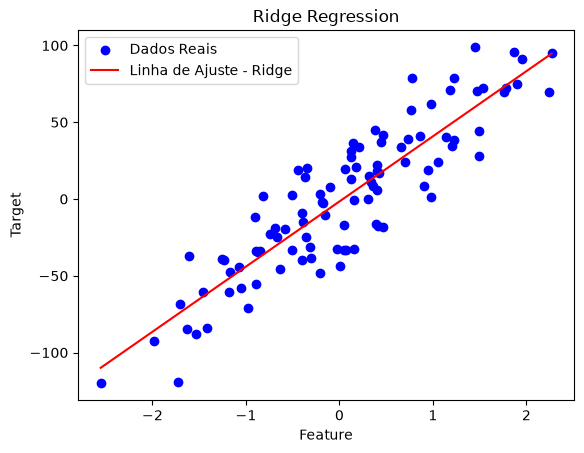

Intercepto: -1.6033791769869385, Coeficiente: 42.43561110102864


In [1]:
from pathlib import Path

import pandas as pd
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt


def resolve_data_path(filename: str, must_exist: bool = True) -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    if must_exist:
        raise FileNotFoundError(
            f"Nao foi possivel localizar o arquivo de dados '{filename}' em {candidates}."
        )

    for candidate in candidates:
        if candidate.parent.exists():
            return candidate.resolve()

    return candidates[0].resolve()


# Carregar os dados
dados = pd.read_csv(resolve_data_path("6.0 - dados_ridge_regression.csv"))

# Preparar os dados
X = dados[['Feature']].values
y = dados['Target'].values

# Criar e treinar o modelo Ridge Regression
modelo_ridge = Ridge(alpha=1.0)  # Experimente com diferentes valores de alpha
modelo_ridge.fit(X, y)

# Coeficientes do modelo
intercepto = modelo_ridge.intercept_
coeficiente = modelo_ridge.coef_[0]

# Previsoes
y_pred = modelo_ridge.predict(X)

# Visualizar os dados e a linha de ajuste
plt.scatter(X, y, color='blue', label='Dados Reais')
plt.plot(X[X[:, 0].argsort()], y_pred[X[:, 0].argsort()], color='red', label='Linha de Ajuste - Ridge')
plt.title('Ridge Regression')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.show()

print(f'Intercepto: {intercepto}, Coeficiente: {coeficiente}')

## Investigação complementar

Compare a nova medida com a figura ou o resultado anterior. Explique qualquer diferença observada.

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, random_state=42)
for alpha in (0.01, 0.1, 1.0):
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    mae_cv = -cross_val_score(pipe, X_treino, y_treino, cv=5, scoring='neg_mean_absolute_error').mean()
    pipe.fit(X_treino, y_treino)
    print(f'alpha={alpha}: coeficiente padronizado={pipe[-1].coef_[0]:.2f}, MAE validação={mae_cv:.2f}, MAE teste={mean_absolute_error(y_teste, pipe.predict(X_teste)):.2f}')
# Extensão: variáveis correlacionadas tornam L1 e L2 mais fáceis de comparar.
import numpy as np
from sklearn.linear_model import Lasso, Ridge
rng_comparacao = np.random.default_rng(42)
X_multi = np.column_stack([
    X[:, 0],
    X[:, 0] + rng_comparacao.normal(scale=0.1, size=len(X)),
    rng_comparacao.normal(size=len(X)),
])
X_multi_treino, X_multi_teste, y_multi_treino, y_multi_teste = train_test_split(
    X_multi, y, test_size=0.25, random_state=42)
for tipo in (Lasso(alpha=1), Ridge(alpha=1)):
    modelo_multi = make_pipeline(StandardScaler(), tipo).fit(X_multi_treino, y_multi_treino)
    print(f'{tipo.__class__.__name__}: coeficientes={np.round(modelo_multi[-1].coef_, 2)}, '
          f'MAE teste={mean_absolute_error(y_multi_teste, modelo_multi.predict(X_multi_teste)):.2f}')

alpha=0.01: coeficiente padronizado=40.92, MAE validação=17.95, MAE teste=17.52
alpha=0.1: coeficiente padronizado=40.87, MAE validação=17.94, MAE teste=17.52
alpha=1.0: coeficiente padronizado=40.38, MAE validação=17.95, MAE teste=17.57
Lasso: coeficientes=[39.56  0.36  0.  ], MAE teste=17.61
Ridge: coeficientes=[23.81 16.85  0.  ], MAE teste=17.87


## Interpretação e limites

O exemplo univariado ilustra encolhimento, mas não demonstra seleção de variáveis.

## Exercício

Compare com Lasso nos mesmos dados e repita com múltiplas características.

Registre a hipótese, a mudança realizada, a métrica ou figura observada e uma conclusão que os dados de fato sustentem.